# Flower Classification With Batch Normalization, Early Stopping, Regularization, and Dropout

This notebook trains a simple flower classifier and then improves it with four important deep-learning techniques:

1. **Batch Normalization** to stabilize hidden-layer activations.
2. **Early Stopping** to stop training before the model overfits.
3. **L2 Regularization** to penalize overly large weights.
4. **Dropout** to reduce co-adaptation between neurons.

The notebook compares a baseline model against an improved model, visualizes validation performance, evaluates predictions on the validation split, and creates a submission file for the test images.


In [1]:
import csv
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

IMG_CHANNELS = 3
PREVIEW_IMAGE_SIZE = (128, 128)
PREVIEW_BATCH_SIZE = 32
VAL_SPLIT = 0.20
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

DATA_DIR = Path('5-flowers-image-classification')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR = DATA_DIR / 'test'
BEST_MODEL_PATH = DATA_DIR / 'best_manual_grid_model_with_es_r_d_bn.keras'

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        'Run this notebook from the project root so the dataset paths resolve correctly.'
    )

class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])
num_classes = len(class_names)
class_to_label = {name: idx for idx, name in enumerate(class_names)}
train_counts = {name: len(list((TRAIN_DIR / name).glob('*.jpg'))) for name in class_names}

print('Images per class:')
for name in class_names:
    print(f'  {name:<10} -> {train_counts[name]}')

print('\nLabel mapping:')
for name, idx in class_to_label.items():
    print(f'  {idx}: {name}')

print(f'\nNumber of classes: {num_classes}')
print(f'Total training images: {sum(train_counts.values())}')
print(f'Test images: {len(list(TEST_DIR.glob("*.jpg")))}')


def make_stratified_split(train_dir, class_to_label, val_split, seed):
    rng = np.random.default_rng(seed)
    train_paths = []
    train_labels = []
    val_paths = []
    val_labels = []

    for class_name in class_names:
        class_paths = np.array(sorted((train_dir / class_name).glob('*.jpg')), dtype=object)
        class_paths = rng.permutation(class_paths)

        if len(class_paths) < 2:
            raise ValueError(
                f"Need at least 2 images in class {class_name!r} for a train/validation split."
            )

        val_count = max(1, int(np.round(len(class_paths) * val_split)))
        val_count = min(len(class_paths) - 1, val_count)

        label = class_to_label[class_name]
        val_class_paths = class_paths[:val_count]
        train_class_paths = class_paths[val_count:]

        train_paths.extend(str(path) for path in train_class_paths)
        train_labels.extend([label] * len(train_class_paths))
        val_paths.extend(str(path) for path in val_class_paths)
        val_labels.extend([label] * len(val_class_paths))

    train_paths = np.array(train_paths)
    train_labels = np.array(train_labels, dtype=np.int32)
    val_paths = np.array(val_paths)
    val_labels = np.array(val_labels, dtype=np.int32)

    train_order = rng.permutation(len(train_paths))
    val_order = rng.permutation(len(val_paths))

    return (
        train_paths[train_order],
        train_labels[train_order],
        val_paths[val_order],
        val_labels[val_order],
    )


def load_labeled_image(path, label, image_size):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=IMG_CHANNELS)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, image_size)
    return image, label


def make_dataset(paths, labels, image_size, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def mapper(path, label):
        return load_labeled_image(path, label, image_size)

    ds = ds.map(mapper, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


train_paths, train_labels, val_paths, val_labels = make_stratified_split(
    TRAIN_DIR,
    class_to_label,
    VAL_SPLIT,
    SEED,
)

train_split_counts = {
    name: int(np.sum(train_labels == class_to_label[name])) for name in class_names
}
val_split_counts = {
    name: int(np.sum(val_labels == class_to_label[name])) for name in class_names
}

missing_val_classes = [name for name in class_names if val_split_counts[name] == 0]
if missing_val_classes:
    raise ValueError(f"Missing classes in val_ds: {missing_val_classes}")

print('Stratified split counts:')
for name in class_names:
    print(
        f"  {name:<10} -> train={train_split_counts[name]:>4}, val={val_split_counts[name]:>3}"
    )

print(f'\nTotal train images: {len(train_paths)}')
print(f'Total validation images: {len(val_paths)}')

train_ds = make_dataset(
    train_paths,
    train_labels,
    PREVIEW_IMAGE_SIZE,
    PREVIEW_BATCH_SIZE,
    shuffle=True,
)
val_ds = make_dataset(
    val_paths,
    val_labels,
    PREVIEW_IMAGE_SIZE,
    PREVIEW_BATCH_SIZE,
    shuffle=False,
)


Images per class:
  daisy      -> 691
  dandelion  -> 951
  rose       -> 694
  sunflower  -> 659
  tulip      -> 870

Label mapping:
  0: daisy
  1: dandelion
  2: rose
  3: sunflower
  4: tulip

Number of classes: 5
Total training images: 3865
Test images: 400
Stratified split counts:
  daisy      -> train= 553, val=138
  dandelion  -> train= 761, val=190
  rose       -> train= 555, val=139
  sunflower  -> train= 527, val=132
  tulip      -> train= 696, val=174

Total train images: 3092
Total validation images: 773


In [2]:
for image_batch, label_batch in train_ds.take(1):
    print('Image batch shape:', image_batch.shape)
    print('Label batch shape:', label_batch.shape)
    print('First 10 labels:', label_batch[:10].numpy())


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
First 10 labels: [3 4 3 4 3 4 4 1 3 3]


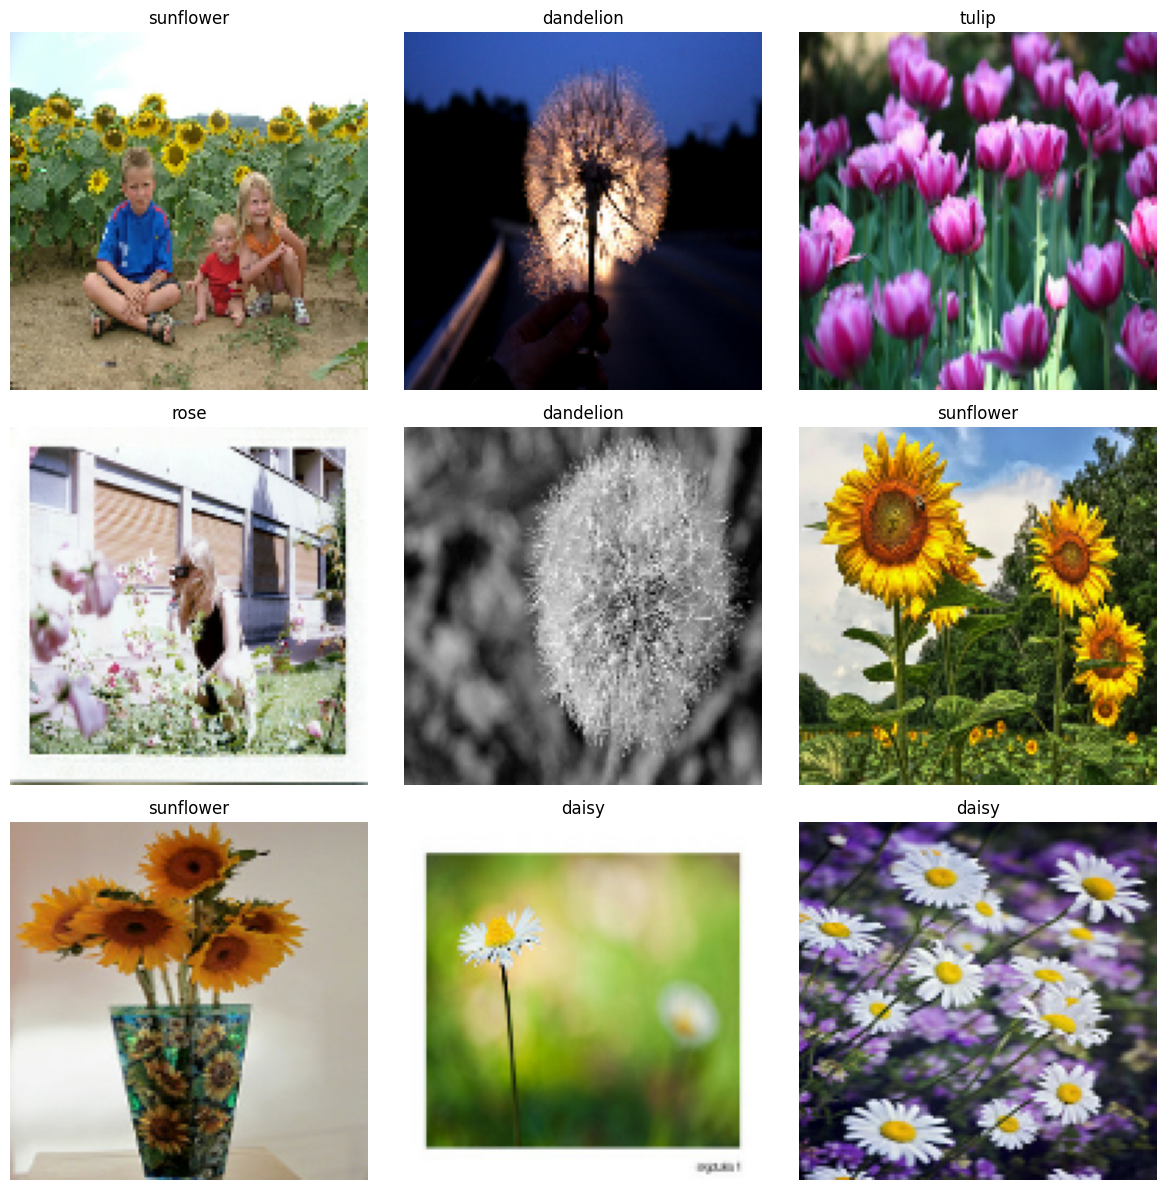

In [3]:
plt.figure(figsize=(12, 12))
for image_batch, label_batch in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy())
        plt.title(class_names[int(label_batch[i].numpy())])
        plt.axis('off')
plt.tight_layout()


In [4]:
batch_sizes = [16, 32]
learning_rates = [0.001, 0.0001]
hidden_node_options = [64, 128]
image_sizes = [(128, 128)]
epoch_options = [10]

dropout_rates = [0.3, 0.5]
l2_values = [0.0001, 0.001]


def build_model(image_size, hidden_nodes, learning_rate, dropout_rate, l2_value):
    img_height, img_width = image_size

    candidate_model = keras.Sequential([
        keras.layers.Input(shape=(img_height, img_width, IMG_CHANNELS)),
        keras.layers.Flatten(),
        keras.layers.Dense(
            hidden_nodes,
            kernel_regularizer=keras.regularizers.l2(l2_value)
        ),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(
            num_classes,
            activation='softmax',
            kernel_regularizer=keras.regularizers.l2(l2_value)
        )
    ])

    candidate_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    return candidate_model


results = []
best_result = None
best_history_dict = None

total_runs = (
    len(batch_sizes)
    * len(image_sizes)
    * len(learning_rates)
    * len(hidden_node_options)
    * len(epoch_options)
    * len(dropout_rates)
    * len(l2_values)
)

current_run = 0

for image_size in image_sizes:
    for batch_size in batch_sizes:
        train_ds = make_dataset(
            train_paths,
            train_labels,
            image_size,
            batch_size,
            shuffle=True,
        )
        val_ds = make_dataset(
            val_paths,
            val_labels,
            image_size,
            batch_size,
            shuffle=False,
        )

        for learning_rate in learning_rates:
            for hidden_nodes in hidden_node_options:
                for epochs in epoch_options:
                    for dropout_rate in dropout_rates:
                        for l2_value in l2_values:
                            current_run += 1
                            print(f'Run {current_run}/{total_runs}')

                            tf.keras.backend.clear_session()

                            candidate_model = build_model(
                                image_size,
                                hidden_nodes,
                                learning_rate,
                                dropout_rate,
                                l2_value,
                            )

                            early_stopping = tf.keras.callbacks.EarlyStopping(
                                monitor='val_accuracy',
                                patience=2,
                                restore_best_weights=True,
                            )

                            candidate_history = candidate_model.fit(
                                train_ds,
                                validation_data=val_ds,
                                epochs=epochs,
                                callbacks=[early_stopping],
                                verbose=0,
                            )

                            val_loss, val_accuracy = candidate_model.evaluate(
                                val_ds,
                                verbose=0,
                            )

                            result = {
                                'batch_size': batch_size,
                                'learning_rate': learning_rate,
                                'hidden_nodes': hidden_nodes,
                                'image_size': image_size,
                                'epochs': epochs,
                                'dropout_rate': dropout_rate,
                                'l2_value': l2_value,
                                'val_loss': float(val_loss),
                                'val_accuracy': float(val_accuracy),
                            }
                            results.append(result)

                            if best_result is None or val_accuracy > best_result['val_accuracy']:
                                candidate_model.save(BEST_MODEL_PATH)
                                best_result = result.copy()
                                best_history_dict = candidate_history.history

results = sorted(results, key=lambda item: item['val_accuracy'], reverse=True)

model = tf.keras.models.load_model(BEST_MODEL_PATH)
history = SimpleNamespace(history=best_history_dict)
best_config = best_result

print('\nBest configuration:')
print(best_config)


Run 1/32

Run 2/32
Run 3/32
Run 4/32
Run 5/32
Run 6/32
Run 7/32
Run 8/32
Run 9/32
Run 10/32
Run 11/32
Run 12/32
Run 13/32
Run 14/32
Run 15/32
Run 16/32
Run 17/32
Run 18/32
Run 19/32
Run 20/32
Run 21/32
Run 22/32
Run 23/32
Run 24/32
Run 25/32
Run 26/32
Run 27/32
Run 28/32
Run 29/32
Run 30/32
Run 31/32
Run 32/32

Best configuration:
{'batch_size': 32, 'learning_rate': 0.001, 'hidden_nodes': 128, 'image_size': (128, 128), 'epochs': 10, 'dropout_rate': 0.3, 'l2_value': 0.0001, 'val_loss': 1.3243591785430908, 'val_accuracy': 0.49288487434387207}


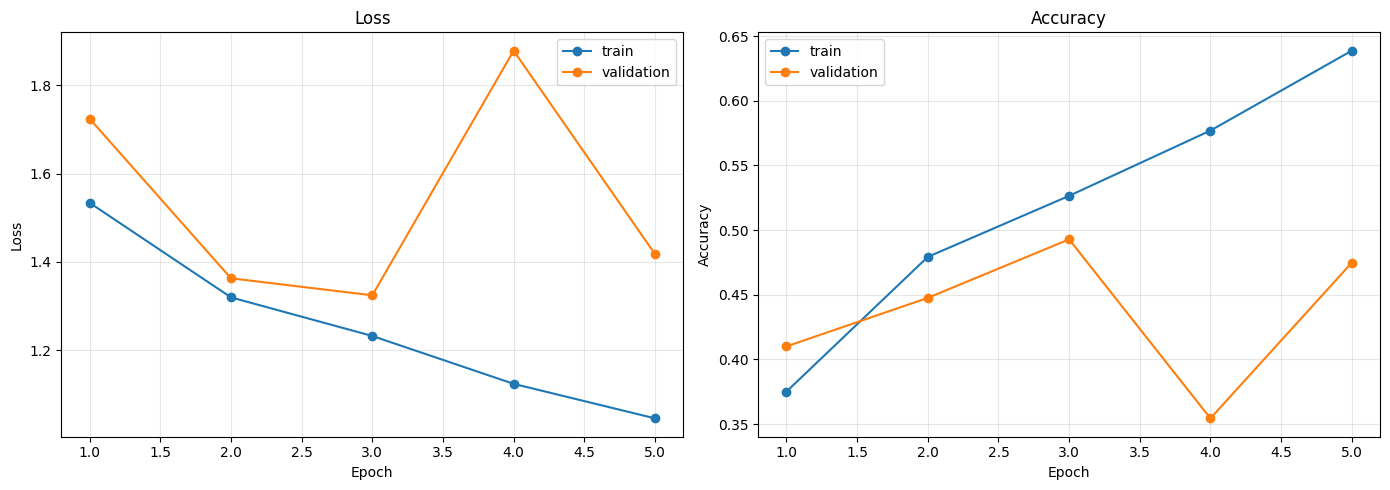

In [5]:
image_size = best_config['image_size']
batch_size = best_config['batch_size']

train_ds = make_dataset(
    train_paths,
    train_labels,
    image_size,
    batch_size,
    shuffle=True,
)
val_ds = make_dataset(
    val_paths,
    val_labels,
    image_size,
    batch_size,
    shuffle=False,
)

history_dict = history.history
epochs_ran = range(1, len(history_dict['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_ran, history_dict['loss'], marker='o', label='train')
axes[0].plot(epochs_ran, history_dict['val_loss'], marker='o', label='validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_ran, history_dict['accuracy'], marker='o', label='train')
axes[1].plot(epochs_ran, history_dict['val_accuracy'], marker='o', label='validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()


Validation loss: 1.3244
Validation accuracy: 0.4929

Per-class validation accuracy:
  daisy      ->  33/138 = 0.2391
  dandelion  -> 134/190 = 0.7053
  rose       ->  29/139 = 0.2086
  sunflower  ->  85/132 = 0.6439
  tulip      -> 100/174 = 0.5747


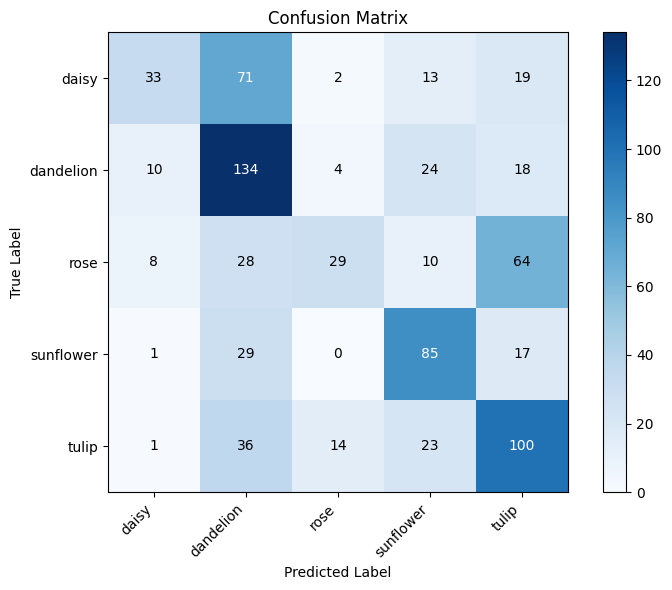

In [6]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)

confusion = tf.math.confusion_matrix(
    y_true,
    y_pred,
    num_classes=num_classes
).numpy()

per_class_totals = confusion.sum(axis=1)
per_class_correct = np.diag(confusion)
per_class_accuracy = np.divide(
    per_class_correct,
    per_class_totals,
    out=np.zeros(num_classes, dtype=np.float64),
    where=per_class_totals > 0,
)

print("\nPer-class validation accuracy:")
for class_idx, class_name in enumerate(class_names):
    print(
        f"  {class_name:<10} -> {per_class_correct[class_idx]:>3}/{per_class_totals[class_idx]:<3}"
        f" = {per_class_accuracy[class_idx]:.4f}"
    )

plt.figure(figsize=(8, 6))
plt.imshow(confusion, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(
            j,
            i,
            str(confusion[i, j]),
            ha='center',
            va='center',
            color='white' if confusion[i, j] > confusion.max() / 2 else 'black'
        )

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [7]:
test_paths = sorted(TEST_DIR.glob('*.jpg'), key=lambda path: int(path.stem))
test_ids = [int(path.stem) for path in test_paths]


def load_test_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, image_size)
    return image


test_ds = tf.data.Dataset.from_tensor_slices([str(path) for path in test_paths])
test_ds = test_ds.map(load_test_image, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

test_probabilities = model.predict(test_ds, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

submission_path = DATA_DIR / 'submission_simple_nonlinear_best_config.csv'
with submission_path.open('w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(['id', 'label'])
    writer.writerows(zip(test_ids, test_predictions))

test_confidences = np.max(test_probabilities, axis=1)

print('Preview of predictions:')
for image_id, predicted_label, confidence in list(zip(test_ids, test_predictions, test_confidences))[:5]:
    predicted_name = class_names[int(predicted_label)]
    print(f'  id={image_id:>3} -> predicted={predicted_name} ({confidence:.2f})')

print(f'Saved submission to: {submission_path.resolve()}')
print()
print('Test set note: correct and misprediction counts cannot be computed on test_ds because test_ds has no ground-truth labels.')
print('Using val_ds for evaluation instead.')

val_probabilities_batches = []
val_labels = []

for images, labels in val_ds:
    val_probabilities_batches.append(model.predict(images, verbose=0))
    val_labels.append(labels.numpy())

val_probabilities = np.concatenate(val_probabilities_batches, axis=0)
val_predictions = np.argmax(val_probabilities, axis=1)
val_confidences = np.max(val_probabilities, axis=1)
y_true = np.concatenate(val_labels, axis=0)

correct = np.sum(val_predictions == y_true)
incorrect = np.sum(val_predictions != y_true)
total = len(y_true)
val_accuracy = correct / total

val_confusion = tf.math.confusion_matrix(y_true, val_predictions, num_classes=num_classes).numpy()
val_per_class_totals = val_confusion.sum(axis=1)
val_per_class_correct = np.diag(val_confusion)
val_per_class_accuracy = np.divide(
    val_per_class_correct,
    val_per_class_totals,
    out=np.zeros(num_classes, dtype=np.float64),
    where=val_per_class_totals > 0,
)

print()
print('Validation results:')
print(f'Total validation images : {total}')
print(f'Correct predictions     : {correct}')
print(f'Mispredictions          : {incorrect}')
print(f'Validation accuracy     : {val_accuracy:.4f}')

print()
print('Per-class validation accuracy:')
for class_idx, class_name in enumerate(class_names):
    print(
        f'  {class_name:<10} -> {val_per_class_correct[class_idx]:>3}/{val_per_class_totals[class_idx]:<3}'
        f' = {val_per_class_accuracy[class_idx]:.4f}'
    )

misclassified_indices = np.where(val_predictions != y_true)[0]

print()
print('First few misclassified validation samples:')
if len(misclassified_indices) == 0:
    print('  None')
else:
    for idx in misclassified_indices[:5]:
        true_idx = int(y_true[idx])
        predicted_idx = int(val_predictions[idx])
        print(
            f'  sample_index={idx}, '
            f'true={class_names[true_idx]}, '
            f'predicted={class_names[predicted_idx]}, '
            f'confidence={val_confidences[idx]:.2f}'
        )


Preview of predictions:
  id=  1 -> predicted=sunflower (0.77)
  id=  2 -> predicted=tulip (0.49)
  id=  3 -> predicted=tulip (0.71)
  id=  4 -> predicted=dandelion (0.40)
  id=  5 -> predicted=dandelion (0.41)
Saved submission to: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\submission_simple_nonlinear_best_config.csv

Test set note: correct and misprediction counts cannot be computed on test_ds because test_ds has no ground-truth labels.
Using val_ds for evaluation instead.

Validation results:
Total validation images : 773
Correct predictions     : 381
Mispredictions          : 392
Validation accuracy     : 0.4929

Per-class validation accuracy:
  daisy      ->  33/138 = 0.2391
  dandelion  -> 134/190 = 0.7053
  rose       ->  29/139 = 0.2086
  sunflower  ->  85/132 = 0.6439
  tulip      -> 100/174 = 0.5747

First few misclassified validation samples:
  sample_index=0, true=tulip, predicted=dandelion, confidence=0.62
  sample_index=1, true=rose, predicted=tulip, confide

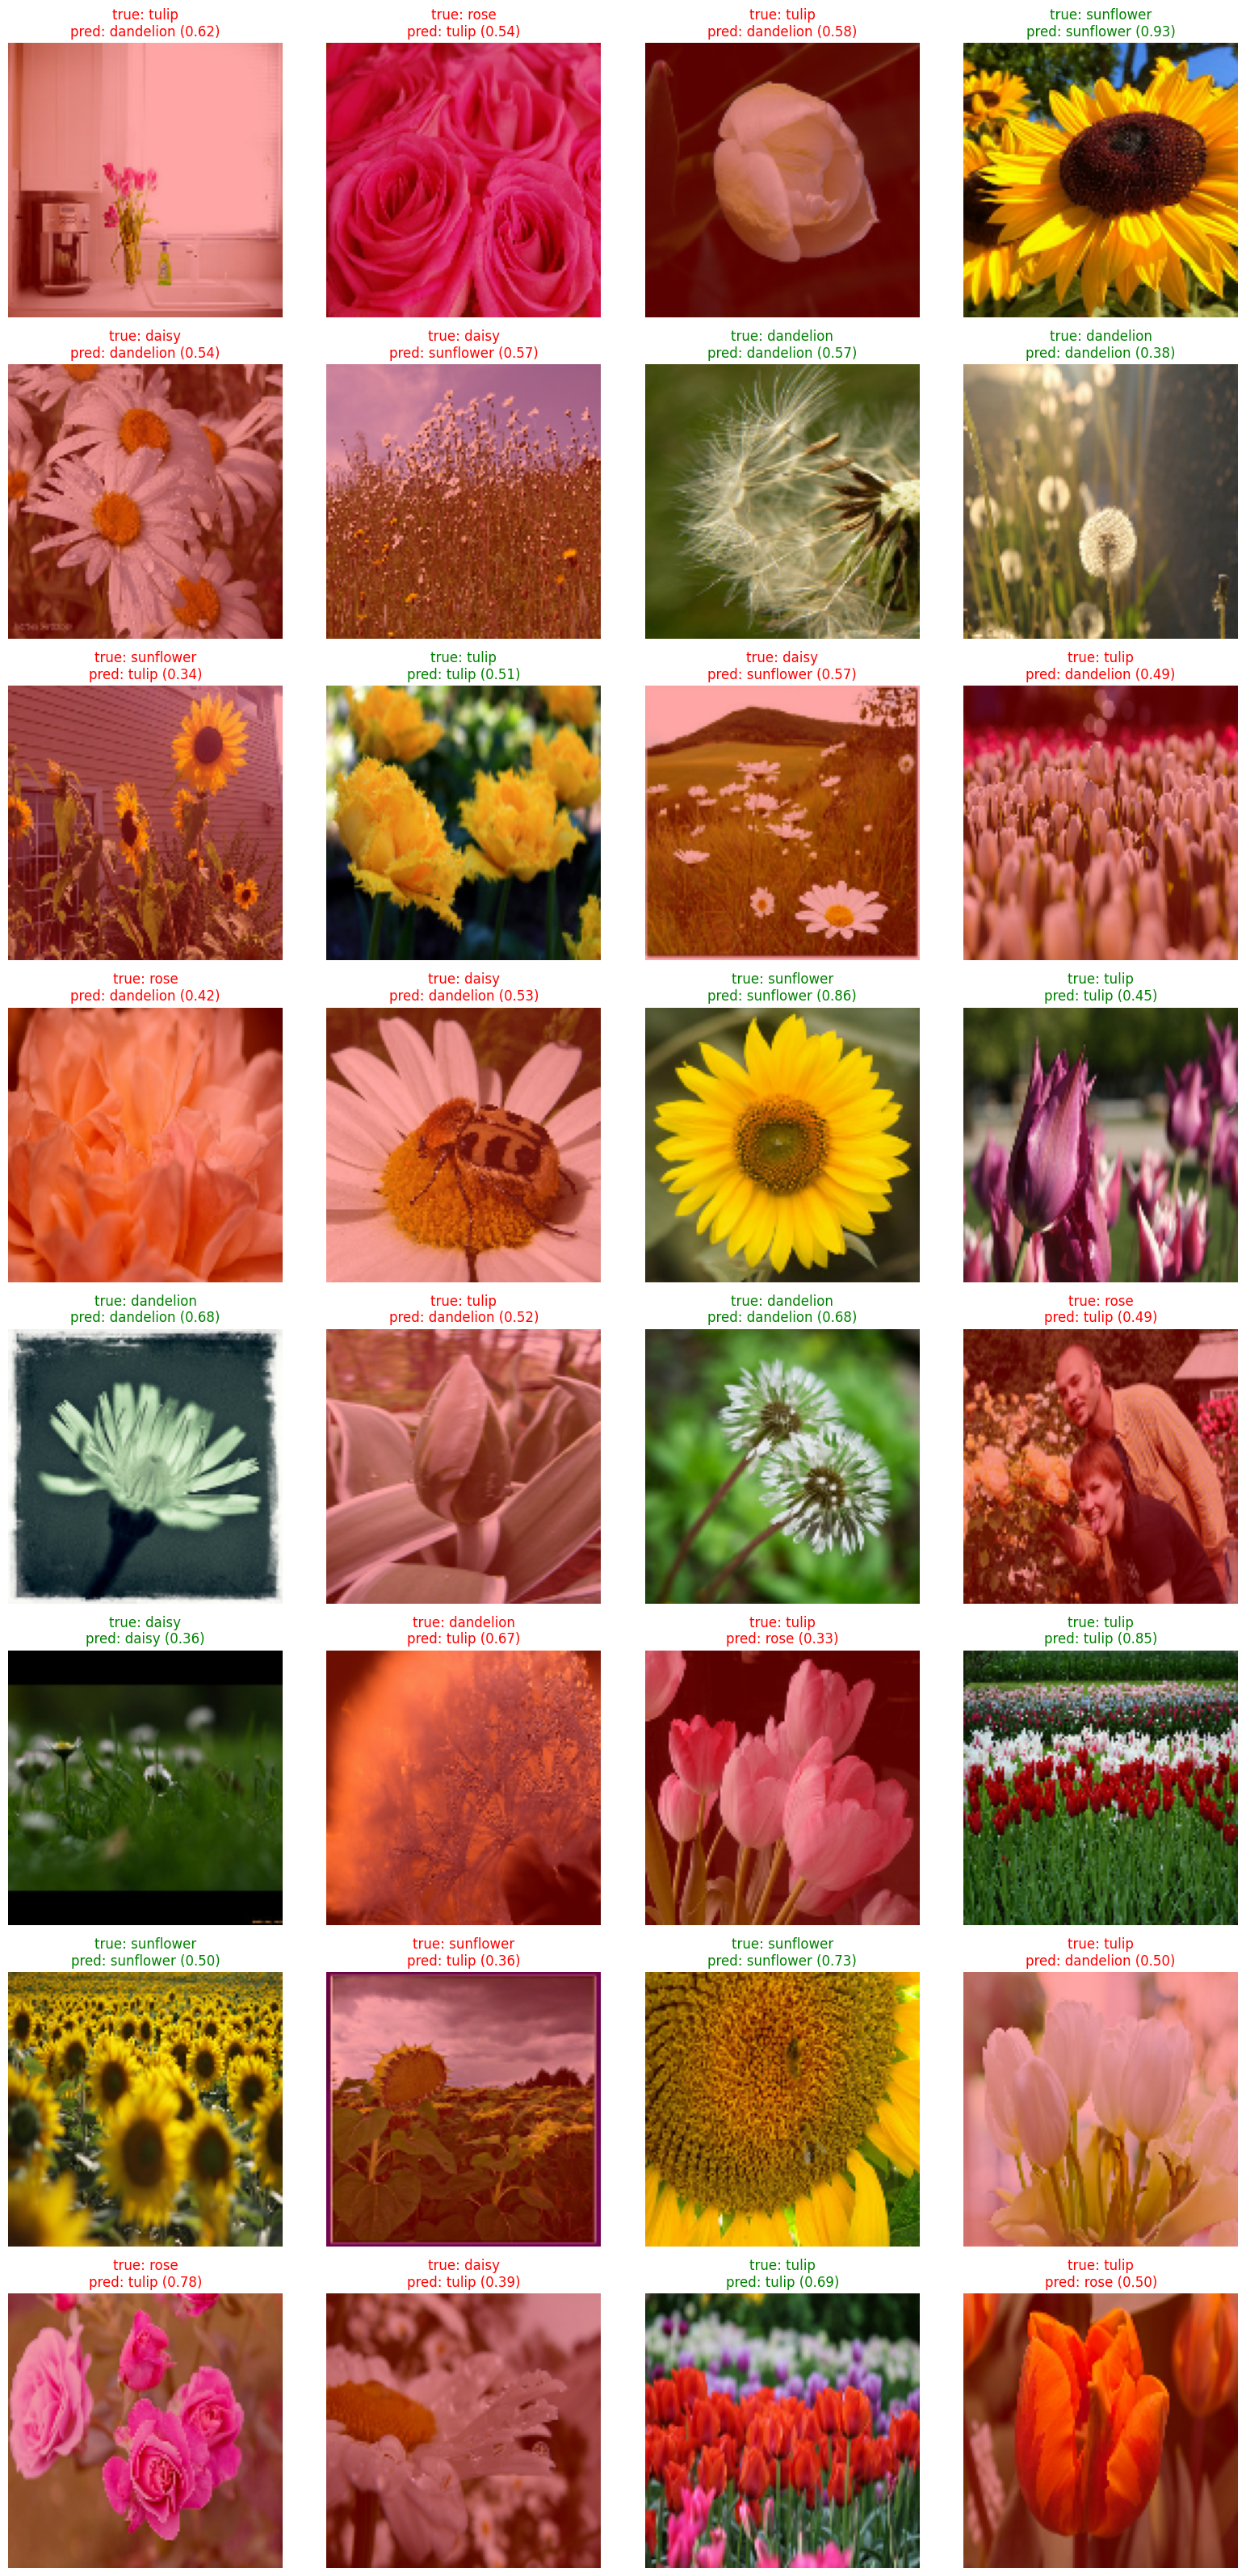

In [8]:
first_val_images, first_val_labels = next(iter(val_ds.take(1)))
first_val_probabilities = model.predict(first_val_images, verbose=0)
first_val_predictions = np.argmax(first_val_probabilities, axis=1)
first_val_confidences = np.max(first_val_probabilities, axis=1)

num_images = len(first_val_predictions)
cols = min(4, num_images)
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(4 * cols, 4 * rows))
for i in range(num_images):
    ax = plt.subplot(rows, cols, i + 1)
    display_image = np.clip(first_val_images[i].numpy(), 0, 1)
    true_idx = int(first_val_labels[i].numpy())
    predicted_idx = int(first_val_predictions[i])
    confidence = first_val_confidences[i]
    is_correct = predicted_idx == true_idx

    if not is_correct:
        red_overlay = np.zeros_like(display_image)
        red_overlay[..., 0] = 1.0
        display_image = 0.65 * display_image + 0.35 * red_overlay

    plt.imshow(display_image)
    title_color = 'green' if is_correct else 'red'
    true_name = class_names[true_idx]
    predicted_name = class_names[predicted_idx]
    plt.title(
        f"true: {true_name}\npred: {predicted_name} ({confidence:.2f})",
        color=title_color,
    )
    plt.axis('off')

plt.tight_layout()
plt.show()
